#### **STEP BY STEP EDA**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
df=pd.read_csv("thyroid_cancer_risk_data.csv")

In [2]:
df.head()
#df.index

,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign


In [3]:
df['Diagnosis'].value_counts()

Diagnosis
Benign       163196
Malignant     49495
Name: count, dtype: int64

In [4]:
#df.shape
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country', 'Ethnicity', 'Family_History',
       'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity',
       'Diabetes', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size',
       'Thyroid_Cancer_Risk', 'Diagnosis'],
      dtype='object')

In [5]:
colms = [
    'Patient_ID', 'Age', 'Gender', 'Country', 'Ethnicity', 'Family_History',
       'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity',
       'Diabetes', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size',
       'Thyroid_Cancer_Risk', 'Diagnosis'
]

for unique_values in colms:
    print(f"{unique_values:30}: {df[unique_values].unique()}\n")
    #{unique_values:30}   Here, :30 gives spacing for clarity of text

Patient_ID                    : [     1      2      3 ... 212689 212690 212691]

Age                           : [66 29 86 75 35 89 38 17 36 67 16 44 52 78 74 47 72 63 73 56 76 61 65 69
 21 87 53 32 18 28 23 85 58 22 49 50 64 20 68 77 48 88 62 54 40 55 43 59
 79 15 25 19 42 26 37 51 41 57 27 46 80 71 84 70 33 82 31 83 30 34 81 45
 39 60 24]

Gender                        : ['Male' 'Female']

Country                       : ['Russia' 'Germany' 'Nigeria' 'India' 'UK' 'South Korea' 'Brazil' 'China'
 'Japan' 'USA']

Ethnicity                     : ['Caucasian' 'Hispanic' 'Asian' 'African' 'Middle Eastern']

Family_History                : ['No' 'Yes']

Radiation_Exposure            : ['Yes' 'No']

Iodine_Deficiency             : ['No' 'Yes']

Smoking                       : ['No' 'Yes']

Obesity                       : ['No' 'Yes']

Diabetes                      : ['No' 'Yes']

TSH_Level                     : [ 9.37  1.83  6.26  4.1   9.1   4.    4.7   5.54  2.3   1.34  9.65  0.53
  6.77  

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212691 entries, 0 to 212690
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Patient_ID           212691 non-null  int64  
 1   Age                  212691 non-null  int64  
 2   Gender               212691 non-null  object 
 3   Country              212691 non-null  object 
 4   Ethnicity            212691 non-null  object 
 5   Family_History       212691 non-null  object 
 6   Radiation_Exposure   212691 non-null  object 
 7   Iodine_Deficiency    212691 non-null  object 
 8   Smoking              212691 non-null  object 
 9   Obesity              212691 non-null  object 
 10  Diabetes             212691 non-null  object 
 11  TSH_Level            212691 non-null  float64
 12  T3_Level             212691 non-null  float64
 13  T4_Level             212691 non-null  float64
 14  Nodule_Size          212691 non-null  float64
 15  Thyroid_Cancer_Ri

In [7]:
#df.isnull().sum()
df.drop(columns='Patient_ID', inplace=True)
df[df['Nodule_Size']==0][['Nodule_Size','Diagnosis']] #.value_counts()

,Nodule_Size,Diagnosis
1075,0.0,Malignant
1415,0.0,Malignant
3271,0.0,Benign
3437,0.0,Benign
4893,0.0,Benign
...,...,...
211223,0.0,Benign
211367,0.0,Benign
211439,0.0,Benign
211830,0.0,Benign


In [8]:
df[df['Nodule_Size'] == 0.0]['Thyroid_Cancer_Risk'].value_counts()


Thyroid_Cancer_Risk
Low       100
Medium     69
High       27
Name: count, dtype: int64

In [9]:
df[df['Nodule_Size'] == 0.0]['Diagnosis'].value_counts()

Diagnosis
Benign       151
Malignant     45
Name: count, dtype: int64

In [10]:
df.describe()

,Age,TSH_Level,T3_Level,T4_Level,Nodule_Size
count,212691.000000,212691.000000,212691.000000,212691.000000,212691.000000
mean,51.918497,5.045102,2.001727,8.246204,2.503403
std,21.632815,2.860264,0.866248,2.164188,1.444631
min,15.000000,0.100000,0.500000,4.500000,0.000000
25%,33.000000,2.570000,1.250000,6.370000,1.250000
50%,52.000000,5.040000,2.000000,8.240000,2.510000
75%,71.000000,7.520000,2.750000,10.120000,3.760000
max,89.000000,10.000000,3.500000,12.000000,5.000000


In [11]:
total_rows = len(df)
zero_nodule_rows = df[df['Nodule_Size'] == 0.0]
proportion = len(zero_nodule_rows) / total_rows * 100

print(f"Nodule_Size == 0.0 rows: {len(zero_nodule_rows)}")
print(f"Percentage in dataset: {proportion:.2f}%")

Nodule_Size == 0.0 rows: 196
Percentage in dataset: 0.09%


In [12]:
zero_nodule_stats = df[df['Nodule_Size'] == 0.0][['TSH_Level', 'T3_Level', 'T4_Level']].describe()
print(zero_nodule_stats)

        TSH_Level   T3_Level    T4_Level
count  196.000000  196.00000  196.000000
mean     4.774643    1.96602    8.093673
std      2.968510    0.85339    2.185528
min      0.300000    0.52000    4.620000
25%      2.227500    1.20000    6.092500
50%      4.415000    1.95500    7.745000
75%      7.175000    2.78250   10.072500
max      9.970000    3.48000   11.990000


##### TSH Levels
- The mean (4.77) and median (4.41) are slightly elevated — possibly indicating hypothyroidism or imbalance.
- But still biologically plausible (not errors)
2. T3 and T4 Levels
- These are within normal ranges for most people:
- T3 normal: ~1.4–4.2
- T4 normal: ~4.5–12.0
- So no extreme outliers or data issues here.
##### Conclusion:
Should Not Drop Nodule_Size == 0.0 Rows Because:
- They’re realistic medically — nodules may not always appear, but risk could still be high.
- They’re only 0.09% of the data — very small proportion.
- Their lab values are valid and may still contribute to learning patterns in ML.

### **UNIVARIATE ANALYSIS**

In [13]:
#df['TSH_Level'].max()
#df['T3_Level'].max()
#df['T4_Level'].max()
#USEFUL FOR BINS RANGE TO STOP  

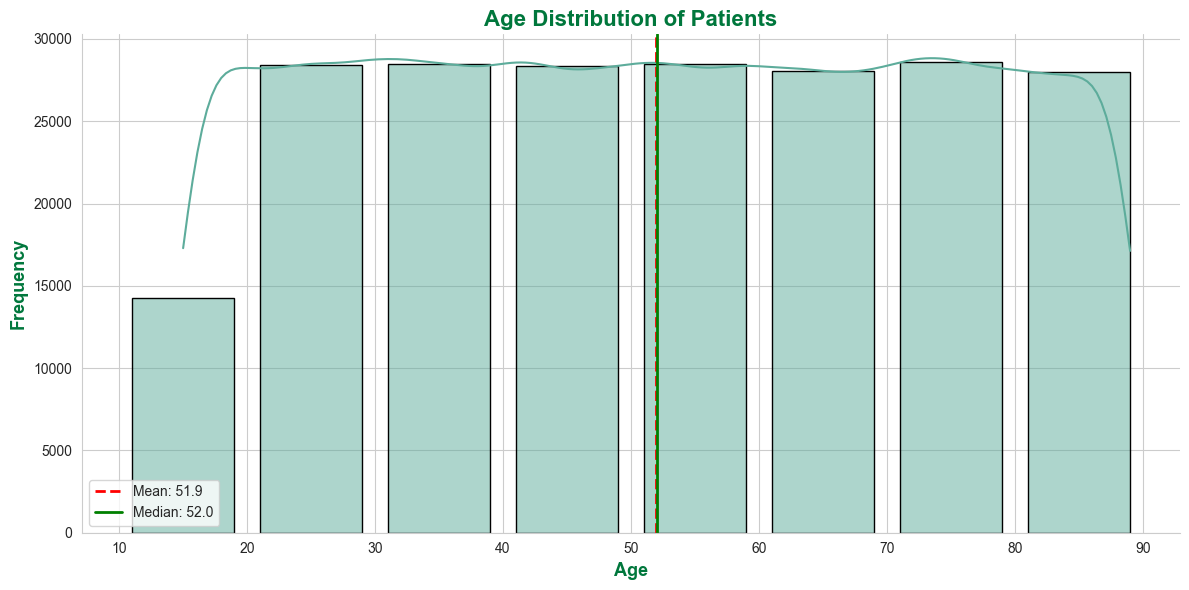

In [14]:

# Sample 
age_data = df['Age']

# Set figure size and style
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create gradient color using custom colormap
#colors = sns.color_palette("coolwarm", as_cmap=True)
# Custom age group bins
bins = [10, 20, 30, 40, 50, 60, 70, 80,90]
#[10-20), [20-30), ..., [80-90)
# Plot histogram with KDE
sns.histplot(age_data,   # type: ignore
             bins=bins, 
             kde=True, 
             
             stat="count", 
             color="#5DAC9B", 
             edgecolor='black',
             shrink=0.8)

# Plot Mean and Median lines
plt.axvline(age_data.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {age_data.mean():.1f}")
plt.axvline(age_data.median(), color='green', linestyle='-', linewidth=2, label=f"Median: {age_data.median():.1f}")

# Title & Labels
plt.title('Age Distribution of Patients', fontsize=16, fontweight='bold',color="#00773C")
plt.xlabel('Age', fontsize=13, fontweight='bold',color="#00773C")
plt.ylabel('Frequency', fontsize=13,fontweight='bold',color="#00773C")
plt.legend()

# Remove top and right spines
sns.despine()

# Show plot
plt.tight_layout()
plt.show()




`Number of bars = Number of bin intervals = len(bins) - 1`

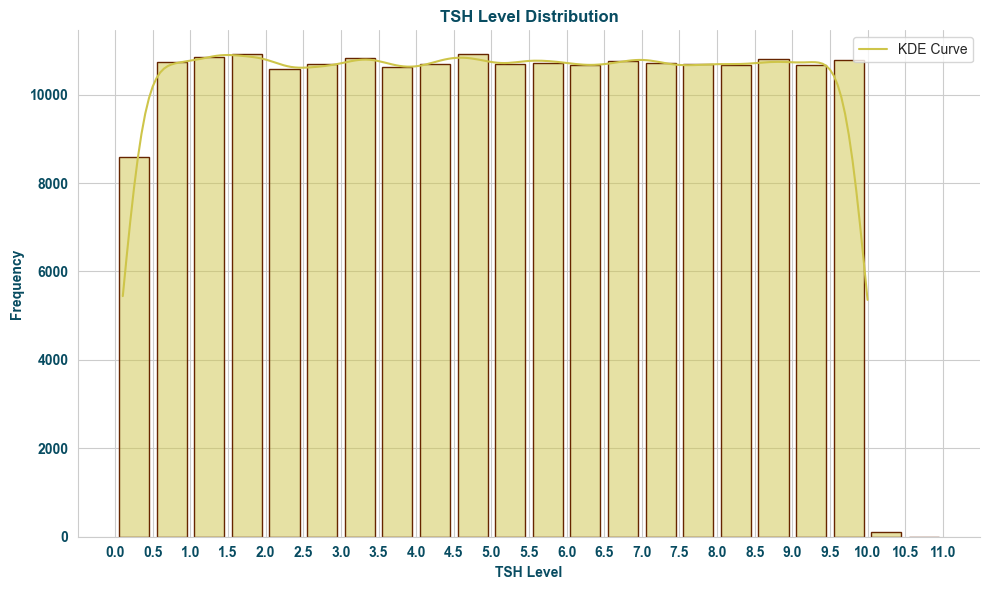

In [15]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Custom bins
bins = [0,0.5, 1,1.5, 2,2.5, 3,3.5, 4, 4.5, 5,5.5,6,6.5,7,7.5,8,8.5,9,9.5,10,10.5,11]

sns.histplot(df['TSH_Level'], # type: ignore
             bins=bins,
             kde=True,
             color="#CEC54A",  # Light lavender
             edgecolor="#662500",
             shrink=0.8)

plt.title('TSH Level Distribution', fontweight='bold', color='#084C61')
plt.xlabel('TSH Level',fontweight='bold', color='#084C61')
plt.xticks(bins,fontweight='bold',color='#084C61')  # For smoother, real-world style ticks
plt.yticks(fontweight='bold',color='#084C61')
plt.ylabel('Frequency', fontweight='bold', color='#084C61')
plt.legend(['KDE Curve'])
sns.despine()
plt.tight_layout()
plt.show()


#### High TSH levels:
- A TSH level above 4.0 mIU/L indicates the thyroid gland is not producing enough thyroid hormones, and the pituitary gland is producing more TSH to compensate. 
- Overt hypothyroidism:
- A TSH level above 10 mIU/L is a strong indication of overt hypothyroidism, where thyroid hormone levels are significantly low. 
#### Subclinical hypothyroidism:
- A TSH level between 4.5 and 10 mIU/L is often referred to as subclinical hypothyroidism, suggesting a mild underactive thyroid. 

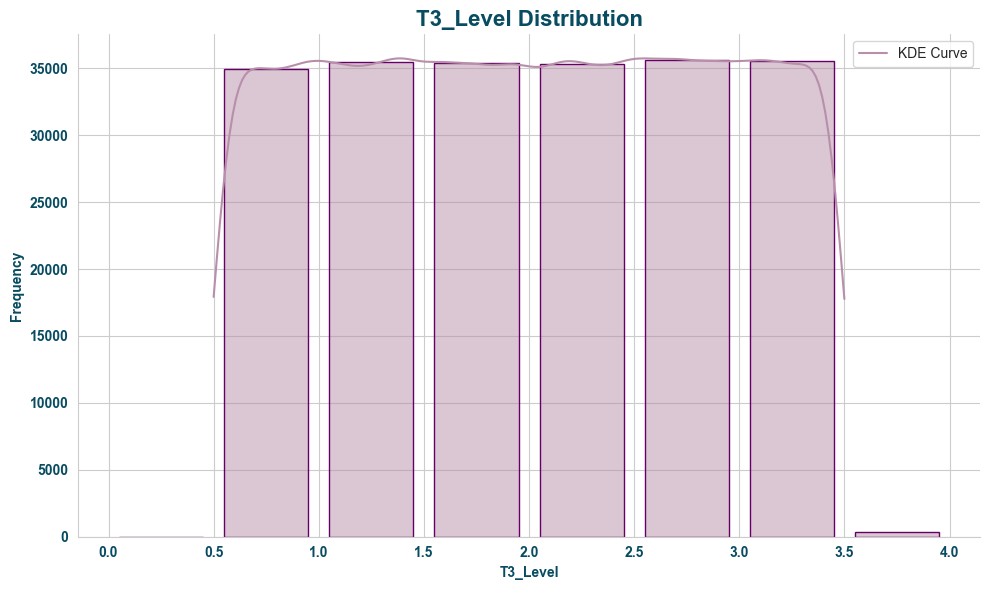

In [16]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Custom bins
bins = [0,0.5, 1,1.5, 2,2.5, 3,3.5, 4]

sns.histplot(df['T3_Level'], # type: ignore
             bins=bins,
             kde=True,
             color="#B88FAA",  # Light lavender
             edgecolor="#660066",
             shrink=0.8)

plt.title('T3_Level Distribution', fontsize=16, fontweight='bold',color='#084C61')
plt.xlabel('T3_Level',fontweight='bold',color='#084C61')
plt.xticks(bins,fontweight='bold',color='#084C61')  # For smoother, real-world style ticks
plt.yticks(fontweight='bold',color='#084C61')
plt.ylabel('Frequency',fontweight='bold',color='#084C61')
plt.legend(['KDE Curve'])
sns.despine()
plt.tight_layout()
plt.show()


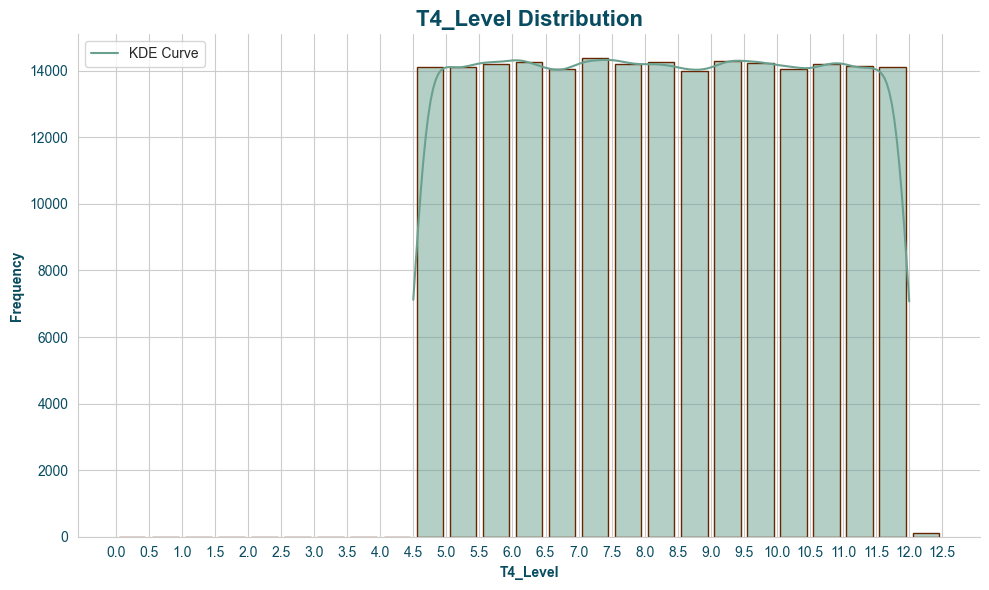

In [17]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Custom bins
bins = [0,0.5, 1,1.5, 2,2.5, 3,3.5, 4, 4.5, 5,5.5,6,6.5,7,7.5,8,8.5,9,9.5,10,10.5,11,11.5,12,12.5]

sns.histplot(df['T4_Level'],  # type: ignore 
             bins=bins,
             kde=True,
             color="#6AA08F",  # Light lavender
             edgecolor="#662700",
             shrink=0.8)

plt.title('T4_Level Distribution', fontsize=16,fontweight='bold', color='#084C61')
plt.xlabel('T4_Level',fontweight='bold', color='#084C61')
plt.xticks(bins,color='#084C61')  # For smoother, real-world style ticks
plt.yticks(color='#084C61')  # For smoother, real-world style ticks

plt.ylabel('Frequency',fontweight='bold', color='#084C61')
plt.legend(['KDE Curve'])
sns.despine()
plt.tight_layout()
plt.show()


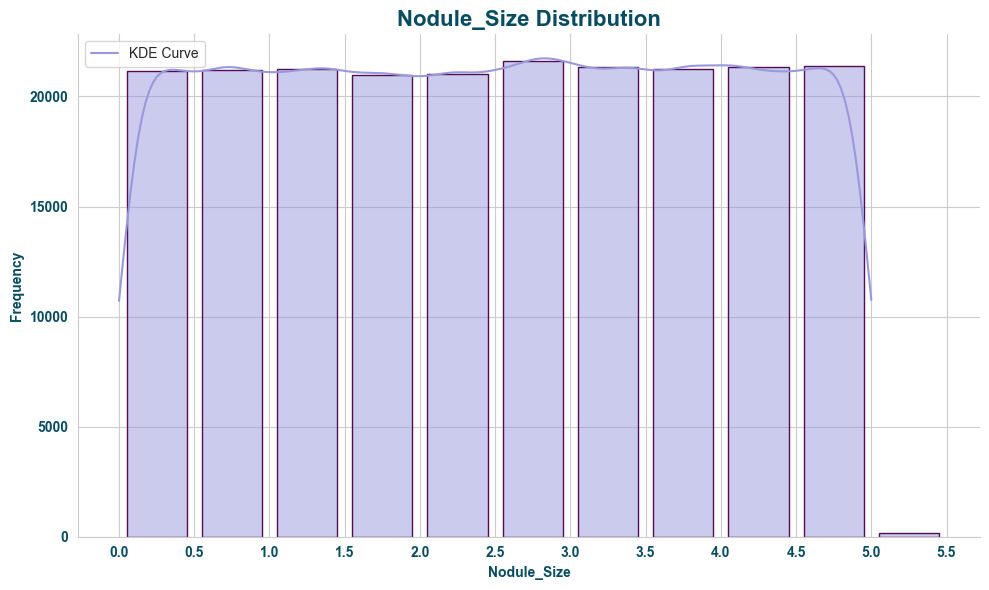

In [18]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

bins = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5]

sns.histplot(df['Nodule_Size'],
             bins=bins,
             kde=True,
             color="#9998DD",  
             edgecolor="#520C52",
             shrink=0.8)  

plt.title('Nodule_Size Distribution', fontsize=16, fontweight='bold', color='#084C61')
plt.xlabel('Nodule_Size', fontweight='bold', color='#084C61')
plt.xticks(bins, fontweight='bold', color='#084C61')
plt.yticks(fontweight='bold', color='#084C61')
plt.ylabel('Frequency', fontweight='bold', color='#084C61')

plt.legend(['KDE Curve'])
sns.despine()
plt.tight_layout()
plt.show()


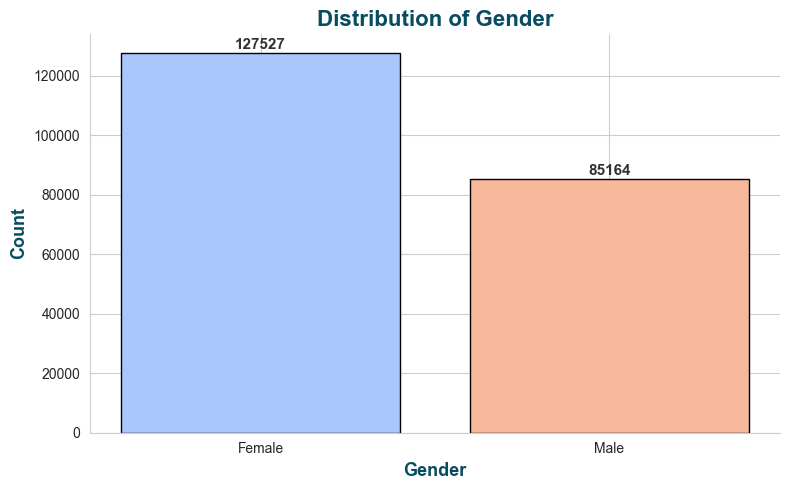

In [19]:

# Set style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(8, 5))

# Use value_counts to get gender counts
gender_counts = df['Gender'].value_counts()

# Custom heatmap-style colors
colors = sns.color_palette("coolwarm", n_colors=len(gender_counts))

# Plot with seaborn (but using matplotlib bar)
bars = plt.bar(gender_counts.index, gender_counts.values, color=colors, edgecolor='black')

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, f'{int(yval)}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold', color="#333333")

# Titles and labels
plt.title('Distribution of Gender', fontsize=16, fontweight='bold', color='#084C61')
plt.xlabel('Gender', fontsize=13, fontweight='bold', color='#084C61')
plt.ylabel('Count', fontsize=13,fontweight='bold', color='#084C61')

# Remove top and right spines for cleaner look
sns.despine()

# Final layout and show
plt.tight_layout()
plt.show()


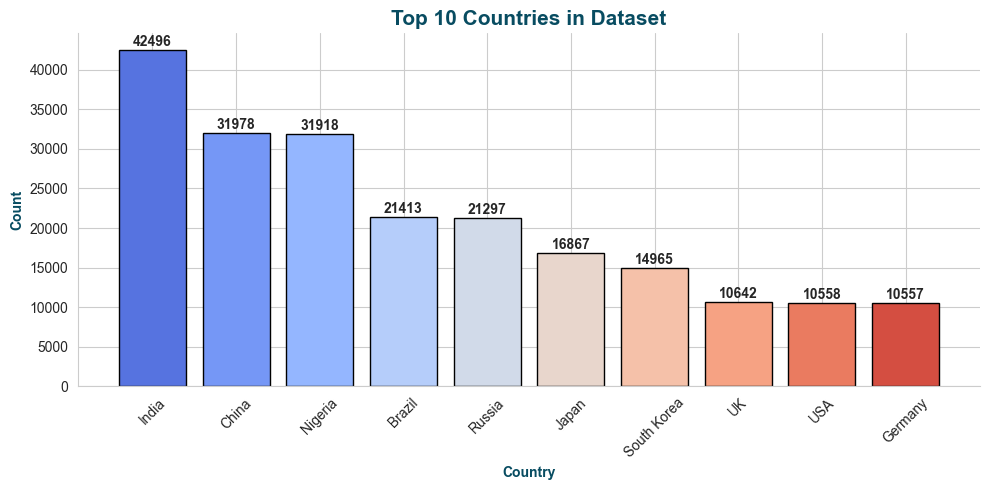

In [20]:
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

country_counts = df['Country'].value_counts().head(10)  # showing top 10 only
colors = sns.color_palette("coolwarm", n_colors=len(country_counts))

bars = plt.bar(country_counts.index, country_counts.values, color=colors, edgecolor='black')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{int(bar.get_height())}', ha='center', fontsize=10, fontweight='bold')

plt.title('Top 10 Countries in Dataset', fontsize=15, fontweight='bold', color='#084C61')
plt.xlabel('Country',fontweight='bold', color='#084C61')
plt.ylabel('Count',fontweight='bold', color='#084C61')
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()


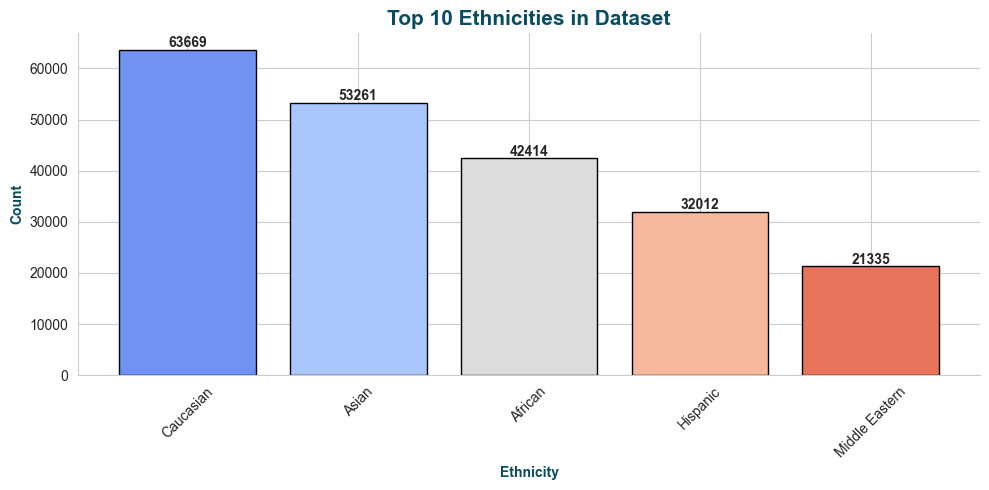

In [21]:
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

eth_counts = df['Ethnicity'].value_counts().head()
colors = sns.color_palette("coolwarm", n_colors=len(eth_counts))

bars = plt.bar(eth_counts.index, eth_counts.values, color=colors, edgecolor='black')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{int(bar.get_height())}', ha='center', fontsize=10, fontweight='bold')

plt.title('Top 10 Ethnicities in Dataset', fontsize=15, fontweight='bold', color='#084C61')
plt.xlabel('Ethnicity',fontweight='bold', color='#084C61')
plt.ylabel('Count',fontweight='bold', color='#084C61')
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()


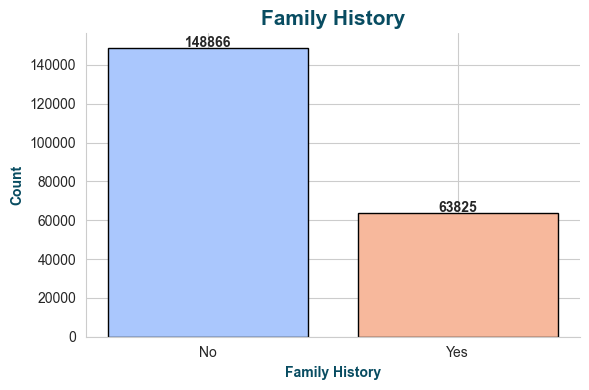

In [22]:
plt.figure(figsize=(6, 4))
sns.set_style("whitegrid")

counts = df['Family_History'].value_counts()
colors = sns.color_palette("coolwarm", n_colors=len(counts))

bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black') # type: ignore

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{int(bar.get_height())}', ha='center', fontsize=10, fontweight='bold')

plt.title('Family History', fontsize=15, fontweight='bold', color='#084C61')
plt.xlabel('Family History',fontweight='bold', color='#084C61')
plt.ylabel('Count',fontweight='bold', color='#084C61')
sns.despine()
plt.tight_layout()
plt.show()


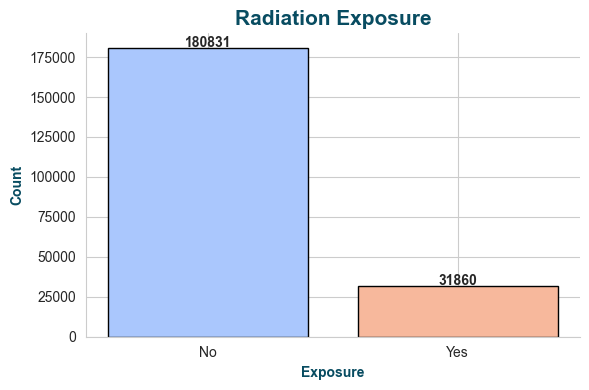

In [23]:
plt.figure(figsize=(6, 4))
sns.set_style("whitegrid")

counts = df['Radiation_Exposure'].value_counts()
colors = sns.color_palette("coolwarm", n_colors=len(counts))

bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black') # type: ignore

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{int(bar.get_height())}', ha='center', fontsize=10, fontweight='bold')

plt.title('Radiation Exposure', fontsize=15, fontweight='bold', color='#084C61')
plt.xlabel('Exposure',fontweight='bold', color='#084C61')
plt.ylabel('Count',fontweight='bold', color='#084C61')
sns.despine()
plt.tight_layout()
plt.show()


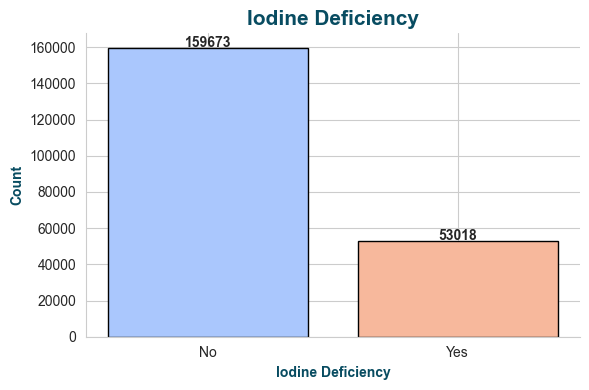

In [24]:
plt.figure(figsize=(6, 4))
sns.set_style("whitegrid")

counts = df['Iodine_Deficiency'].value_counts()
colors = sns.color_palette("coolwarm", n_colors=len(counts))

bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black') # type: ignore

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{int(bar.get_height())}', ha='center', fontsize=10, fontweight='bold')

plt.title('Iodine Deficiency', fontsize=15, fontweight='bold', color='#084C61')
plt.xlabel('Iodine Deficiency',fontweight='bold', color='#084C61')
plt.ylabel('Count',fontweight='bold', color='#084C61')
sns.despine()
plt.tight_layout()
plt.show()


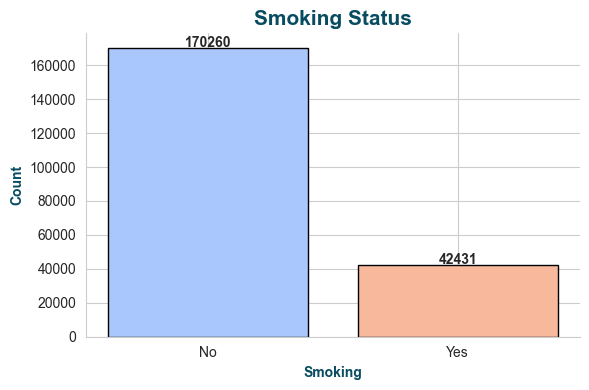

In [25]:
plt.figure(figsize=(6, 4))
sns.set_style("whitegrid")

counts = df['Smoking'].value_counts()
colors = sns.color_palette("coolwarm", n_colors=len(counts))

bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{int(bar.get_height())}', ha='center', fontsize=10, fontweight='bold')

plt.title('Smoking Status', fontsize=15, fontweight='bold', color='#084C61')
plt.xlabel('Smoking',fontweight='bold', color='#084C61')
plt.ylabel('Count',fontweight='bold', color='#084C61')
sns.despine()
plt.tight_layout()
plt.show()


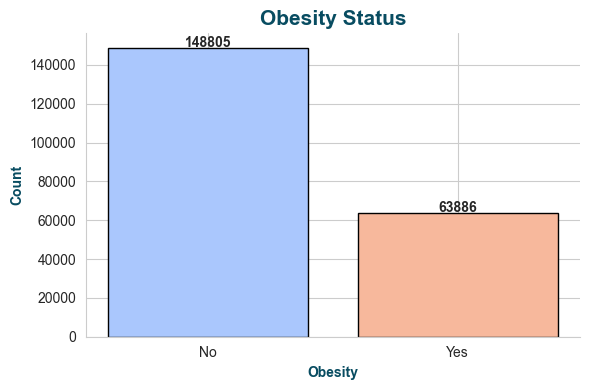

In [26]:
plt.figure(figsize=(6, 4))
sns.set_style("whitegrid")

counts = df['Obesity'].value_counts()
colors = sns.color_palette("coolwarm", n_colors=len(counts))

bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{int(bar.get_height())}', ha='center', fontsize=10, fontweight='bold')

plt.title('Obesity Status', fontsize=15,fontweight='bold', color='#084C61')
plt.xlabel('Obesity',fontweight='bold', color='#084C61')
plt.ylabel('Count',fontweight='bold', color='#084C61')
sns.despine()
plt.tight_layout()
plt.show()


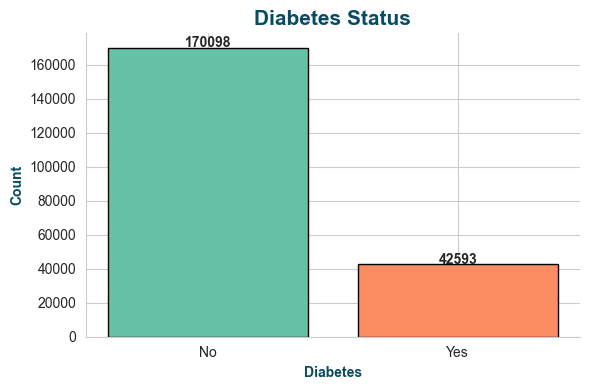

In [27]:
plt.figure(figsize=(6, 4))
sns.set_style("whitegrid")

counts = df['Diabetes'].value_counts()
colors = sns.color_palette("Set2", n_colors=len(counts))

bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{int(bar.get_height())}', ha='center', fontsize=10, fontweight='bold')

plt.title('Diabetes Status', fontsize=15, fontweight='bold', color='#084C61')
plt.xlabel('Diabetes',fontweight='bold', color='#084C61')
plt.ylabel('Count',fontweight='bold', color='#084C61')
sns.despine()
plt.tight_layout()
plt.show()


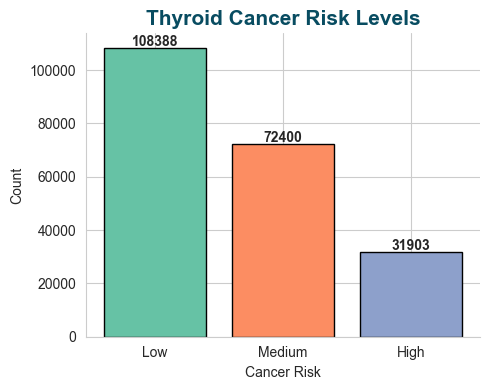

In [68]:
plt.figure(figsize=(5, 4))
sns.set_style("whitegrid")

counts = df['Thyroid_Cancer_Risk'].value_counts()
colors = sns.color_palette("Set2", n_colors=len(counts))  # Different color scheme

bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{int(bar.get_height())}', ha='center', fontsize=10, fontweight='bold')

plt.title('Thyroid Cancer Risk Levels', fontsize=15, fontweight='bold', color='#084C61')
plt.xlabel('Cancer Risk')
plt.ylabel('Count')
sns.despine()
plt.tight_layout()
plt.show()


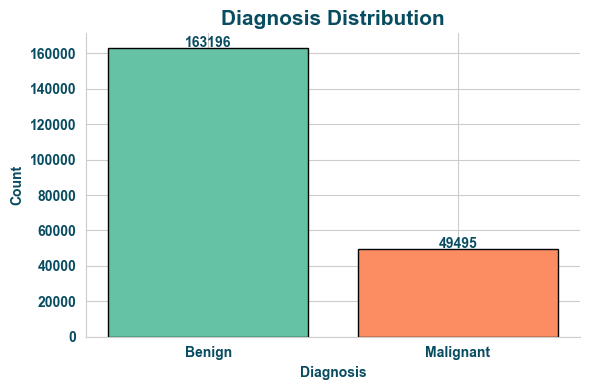

In [29]:
plt.figure(figsize=(6, 4))
sns.set_style("whitegrid")

counts = df['Diagnosis'].value_counts()
colors = sns.color_palette("Set2", n_colors=len(counts))  # Same unique palette

bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black')  # type: ignore

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{int(bar.get_height())}', ha='center', fontsize=10,fontweight='bold',color='#084C61')

plt.title('Diagnosis Distribution', fontsize=15, fontweight='bold', color='#084C61')
plt.xlabel('Diagnosis',fontweight='bold',color='#084C61')
plt.ylabel('Count',fontweight='bold',color='#084C61')
plt.xticks(fontweight='bold',color='#084C61')
plt.yticks(fontweight='bold',color='#084C61')
sns.despine()
plt.tight_layout()
plt.show()


#### **Why are there 4 Quartiles if we only see Q1, Q2, Q3?**

Q1, Q2 (Median), and Q3 are three **cut points** that divide the data into **four equal parts**:

- 0% to 25% → 1st Quartile  
- 25% to 50% → 2nd Quartile  
- 50% to 75% → 3rd Quartile  
- 75% to 100% → 4th Quartile
- So, 3 cut points = 4 quartiles!


#### **OUTLIER DETECTION USING BOX-PLOTS**

In [30]:
# OUTLIER DETECTION USING THE NUMERICAL METHOD
#Inter-Quartile Range
#IQR Calculation
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

# Defining the bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 3: Filter outliers
outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]

# Step 4: Print number and sample of outliers
print(f"Total Outliers in Age column: {outliers.shape[0]}")
print("\nThe Sample Outlier Values are:")
print(outliers['Age'].value_counts().head(10))


Total Outliers in Age column: 0

The Sample Outlier Values are:
Series([], Name: count, dtype: int64)


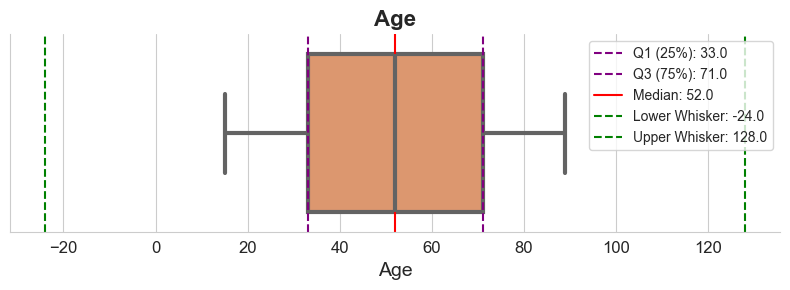

In [31]:
# Calculate stats
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR
median = df['Age'].median()


plt.figure(figsize=(8, 3))
sns.set_style("whitegrid")

# Boxplot
sns.boxplot(x=df['Age'], color="#EE925D", linewidth=3)

# Add lines for stats
plt.axvline(Q1, color='purple', linestyle='--', label=f'Q1 (25%): {Q1:.1f}')
plt.axvline(Q3, color='purple', linestyle='--', label=f'Q3 (75%): {Q3:.1f}')
plt.axvline(median, color='red', linestyle='-', label=f'Median: {median:.1f}')
plt.axvline(lower_whisker, color='green', linestyle='--', label=f'Lower Whisker: {lower_whisker:.1f}')
plt.axvline(upper_whisker, color='green', linestyle='--', label=f'Upper Whisker: {upper_whisker:.1f}')

# Titles & Labels
plt.title("Age", fontsize=16, fontweight='bold')
plt.xlabel("Age", fontsize=14)
plt.xticks(fontsize=12)
plt.legend(loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()


In [32]:
# OUTLIER DETECTION USING THE NUMERICAL METHOD
#Inter-Quartile Range
#IQR Calculation
Q1 = df['TSH_Level'].quantile(0.25)
Q3 = df['TSH_Level'].quantile(0.75)
IQR = Q3 - Q1

# Defining the bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
outliers = df[(df['TSH_Level'] < lower_bound) | (df['TSH_Level'] > upper_bound)]

# Step 4: Print number and sample of outliers
print(f"Total Outliers in TSH_Level column: {outliers.shape[0]}")
print("\nThe Sample Outlier Values are:")
print(outliers['TSH_Level'].value_counts().head(10))

Total Outliers in TSH_Level column: 0

The Sample Outlier Values are:
Series([], Name: count, dtype: int64)


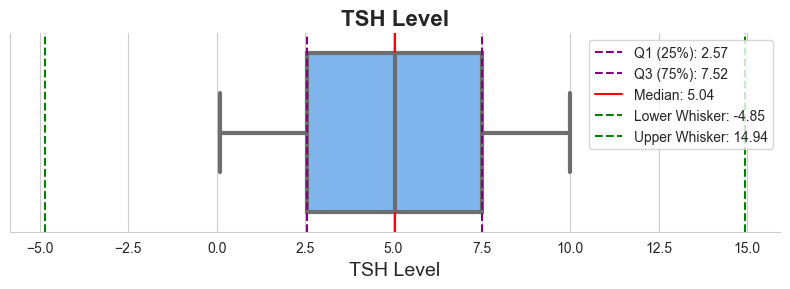

In [33]:
# TSH_Level stats
Q1 = df['TSH_Level'].quantile(0.25)
Q3 = df['TSH_Level'].quantile(0.75)
IQR = Q3 - Q1
lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR
median = df['TSH_Level'].median()


plt.figure(figsize=(8, 3))
sns.set_style("whitegrid")
sns.boxplot(x=df['TSH_Level'], color="#6EB5FF", linewidth=3)

plt.axvline(Q1, color='purple', linestyle='--', label=f'Q1 (25%): {Q1:.2f}')
plt.axvline(Q3, color='purple', linestyle='--', label=f'Q3 (75%): {Q3:.2f}')
plt.axvline(median, color='red', linestyle='-', label=f'Median: {median:.2f}')
plt.axvline(lower_whisker, color='green', linestyle='--', label=f'Lower Whisker: {lower_whisker:.2f}')
plt.axvline(upper_whisker, color='green', linestyle='--', label=f'Upper Whisker: {upper_whisker:.2f}')

plt.title("TSH Level", fontsize=16, fontweight='bold')
plt.xlabel("TSH Level", fontsize=14)
plt.legend(loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()


In [34]:
# OUTLIER DETECTION USING THE NUMERICAL METHOD
#Inter-Quartile Range
#IQR Calculation
Q1 = df['T3_Level'].quantile(0.25)
Q3 = df['T3_Level'].quantile(0.75)
IQR = Q3 - Q1

# Defining the bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
outliers = df[(df['T3_Level'] < lower_bound) | (df['T3_Level'] > upper_bound)]

# Step 4: Print number and sample of outliers
print(f"Total Outliers in 'T3_Level' column: {outliers.shape[0]}")
print("\nThe Sample Outlier Values are:")
print(outliers['T3_Level'].value_counts().head(10))

Total Outliers in 'T3_Level' column: 0

The Sample Outlier Values are:
Series([], Name: count, dtype: int64)


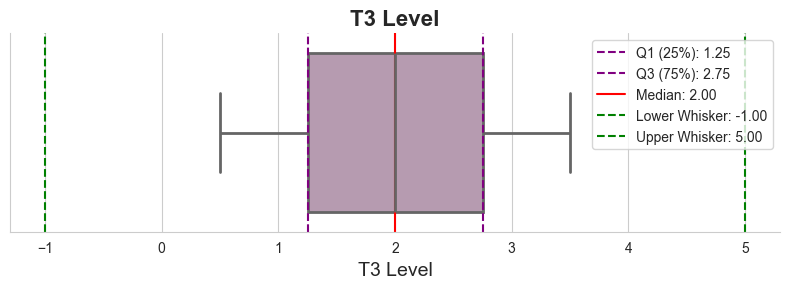

In [35]:
# T3_Level stats
Q1 = df['T3_Level'].quantile(0.25)
Q3 = df['T3_Level'].quantile(0.75)
IQR = Q3 - Q1
lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR
median = df['T3_Level'].median()


plt.figure(figsize=(8, 3))
sns.set_style("whitegrid")
sns.boxplot(x=df['T3_Level'], color="#BB96B2", linewidth=2)

plt.axvline(Q1, color='purple', linestyle='--', label=f'Q1 (25%): {Q1:.2f}')
plt.axvline(Q3, color='purple', linestyle='--', label=f'Q3 (75%): {Q3:.2f}')
plt.axvline(median, color='red', linestyle='-', label=f'Median: {median:.2f}')
plt.axvline(lower_whisker, color='green', linestyle='--', label=f'Lower Whisker: {lower_whisker:.2f}')
plt.axvline(upper_whisker, color='green', linestyle='--', label=f'Upper Whisker: {upper_whisker:.2f}')

plt.title("T3 Level", fontsize=16, fontweight='bold')
plt.xlabel("T3 Level", fontsize=14)
plt.legend(loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()


In [36]:
# OUTLIER DETECTION USING THE NUMERICAL METHOD
#Inter-Quartile Range
#IQR Calculation
Q1 = df['T4_Level'].quantile(0.25)
Q3 = df['T4_Level'].quantile(0.75)
IQR = Q3 - Q1

# Defining the bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
outliers = df[(df['T4_Level'] < lower_bound) | (df['T4_Level'] > upper_bound)]

# Step 4: Print number and sample of outliers
print(f"Total Outliers in 'T4_Level' column: {outliers.shape[0]}")
print("\nThe Sample Outlier Values are:")
print(outliers['T4_Level'].value_counts().head(10))

Total Outliers in 'T4_Level' column: 0

The Sample Outlier Values are:
Series([], Name: count, dtype: int64)


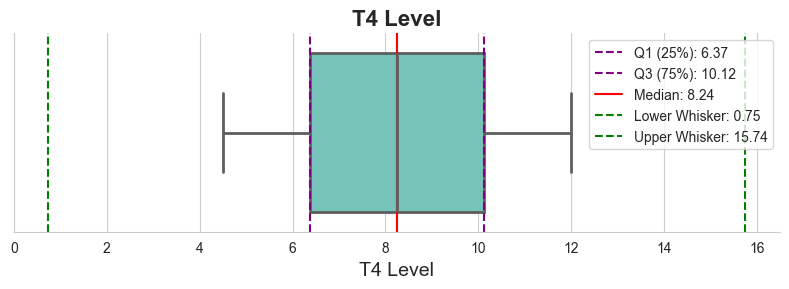

In [37]:
# T4_Level stats
Q1 = df['T4_Level'].quantile(0.25)
Q3 = df['T4_Level'].quantile(0.75)
IQR = Q3 - Q1
lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR
median = df['T4_Level'].median()


plt.figure(figsize=(8, 3))
sns.set_style("whitegrid")
sns.boxplot(x=df['T4_Level'], color="#69D0C4", linewidth=2)

plt.axvline(Q1, color='purple', linestyle='--', label=f'Q1 (25%): {Q1:.2f}')
plt.axvline(Q3, color='purple', linestyle='--', label=f'Q3 (75%): {Q3:.2f}')
plt.axvline(median, color='red', linestyle='-', label=f'Median: {median:.2f}')
plt.axvline(lower_whisker, color='green', linestyle='--', label=f'Lower Whisker: {lower_whisker:.2f}')
plt.axvline(upper_whisker, color='green', linestyle='--', label=f'Upper Whisker: {upper_whisker:.2f}')

plt.title("T4 Level", fontsize=16, fontweight='bold')
plt.xlabel("T4 Level", fontsize=14)
plt.legend(loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()


In [38]:
# OUTLIER DETECTION USING THE NUMERICAL METHOD
#Inter-Quartile Range
#IQR Calculation
Q1 = df['Nodule_Size'].quantile(0.25)
Q3 = df['Nodule_Size'].quantile(0.75)
IQR = Q3 - Q1

# Defining the bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
outliers = df[(df['Nodule_Size'] < lower_bound) | (df['Nodule_Size'] > upper_bound)]

# Step 4: Print number and sample of outliers
print(f"Total Outliers in 'Nodule_Size' column: {outliers.shape[0]}")
print("\nThe Sample Outlier Values are:")
print(outliers['Nodule_Size'].value_counts().head(10))

Total Outliers in 'Nodule_Size' column: 0

The Sample Outlier Values are:
Series([], Name: count, dtype: int64)


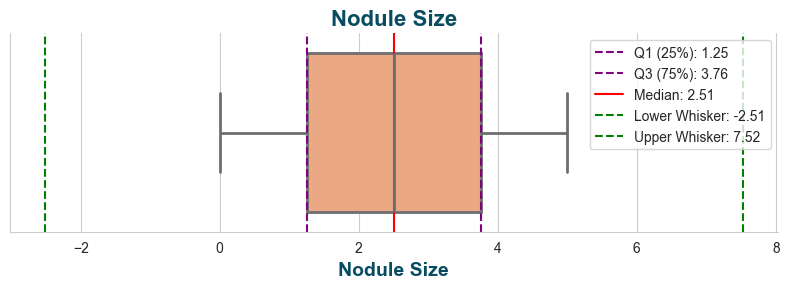

In [39]:
# Nodule_Size stats
Q1 = df['Nodule_Size'].quantile(0.25)
Q3 = df['Nodule_Size'].quantile(0.75)
IQR = Q3 - Q1
lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR
median = df['Nodule_Size'].median()

plt.figure(figsize=(8, 3))
sns.set_style("whitegrid")
sns.boxplot(x=df['Nodule_Size'], color="#FCA373", linewidth=2)

plt.axvline(Q1, color='purple', linestyle='--', label=f'Q1 (25%): {Q1:.2f}')
plt.axvline(Q3, color='purple', linestyle='--', label=f'Q3 (75%): {Q3:.2f}')
plt.axvline(median, color='red', linestyle='-', label=f'Median: {median:.2f}')
plt.axvline(lower_whisker, color='green', linestyle='--', label=f'Lower Whisker: {lower_whisker:.2f}')
plt.axvline(upper_whisker, color='green', linestyle='--', label=f'Upper Whisker: {upper_whisker:.2f}')

plt.title("Nodule Size", fontsize=16, fontweight='bold', color='#084C61')
plt.xlabel("Nodule Size", fontsize=14,fontweight='bold', color='#084C61')
plt.legend(loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()


#### **MEASURING CLASS IMBALANCE**

In [40]:
counts = df['Thyroid_Cancer_Risk'].value_counts()
majority = counts.max()       # 108388 (Low)
minority = counts.min()       # 31903 (High)
imbalance_ratio = majority / minority
print(imbalance_ratio)

3.3974234398018996


In [41]:
counts = df['Thyroid_Cancer_Risk'].value_counts(normalize=True) * 100
#normalize=True return category wise percentage
print(counts.round(2))


Thyroid_Cancer_Risk
Low       50.96
Medium    34.04
High      15.00
Name: proportion, dtype: float64


C:\Users\Hp\AppData\Local\Temp\ipykernel_9652\292505350.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=colors)


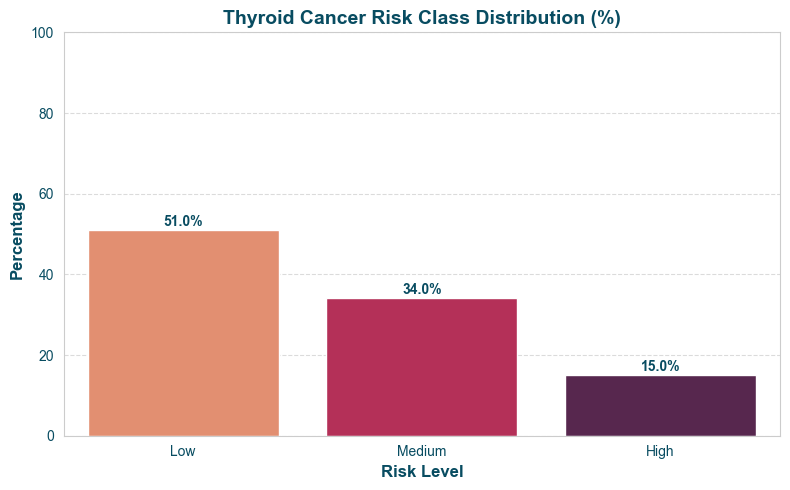

In [42]:
# Value counts in %
counts = df['Thyroid_Cancer_Risk'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
colors = sns.color_palette("rocket_r", len(counts))  # reverse rocket 
sns.barplot(x=counts.index, y=counts.values, palette=colors)

plt.title('Thyroid Cancer Risk Class Distribution (%)', fontsize=14, fontweight='bold', color='#084C61')
plt.ylabel('Percentage', fontsize=12, fontweight='bold', color='#084C61')
plt.xlabel('Risk Level', fontsize=12, fontweight='bold', color='#084C61')
plt.xticks(color='#084C61')
plt.yticks(color='#084C61')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, val in enumerate(counts.values):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center',fontweight='bold', color='#084C61')

plt.tight_layout()
plt.show()


#### What this tells us:
- High risk class is underrepresented
- This imbalance could cause models to ignore High-risk cases, predicting mostly “Low” or “Medium”

### **Bi-Variate Analysis**

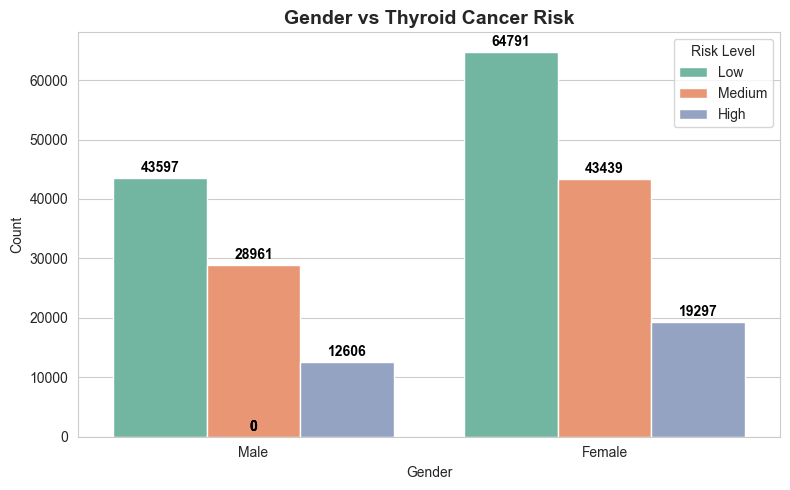

In [43]:
#In Seaborn plots, hue is a grouping variable which:
#breaks categories into same x-axis values using different colors
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Gender', hue='Thyroid_Cancer_Risk', palette='Set2')

plt.title("Gender vs Thyroid Cancer Risk", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title='Risk Level')

# Add counts on top of each bar
for p in ax.patches:
    height = p.get_height()  # type: ignore
    ax.text(
        p.get_x() + p.get_width() / 2,   # X-position (center of bar)  # type: ignore
        height + 500,                    # Y-position (just above the bar)
        f'{int(height)}',                # Text (count value)
        ha='center', va='bottom', 
        fontsize=10, fontweight='bold', color='black'
    )

plt.tight_layout()
plt.show()

#What's Happening Here:
#ax = sns.countplot(...) → Seaborn returns object in which there are bars (patches)
#for p in ax.patches: Loops runs on every bar (rectangle)
#p.get_height() → Bar ki height (count)
#ax.text() →Writes text on that bar




C:\Users\Hp\AppData\Local\Temp\ipykernel_9652\1900735649.py:3: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  ax=sns.countplot(data=df, x='Country', hue='Thyroid_Cancer_Risk', palette=palette)


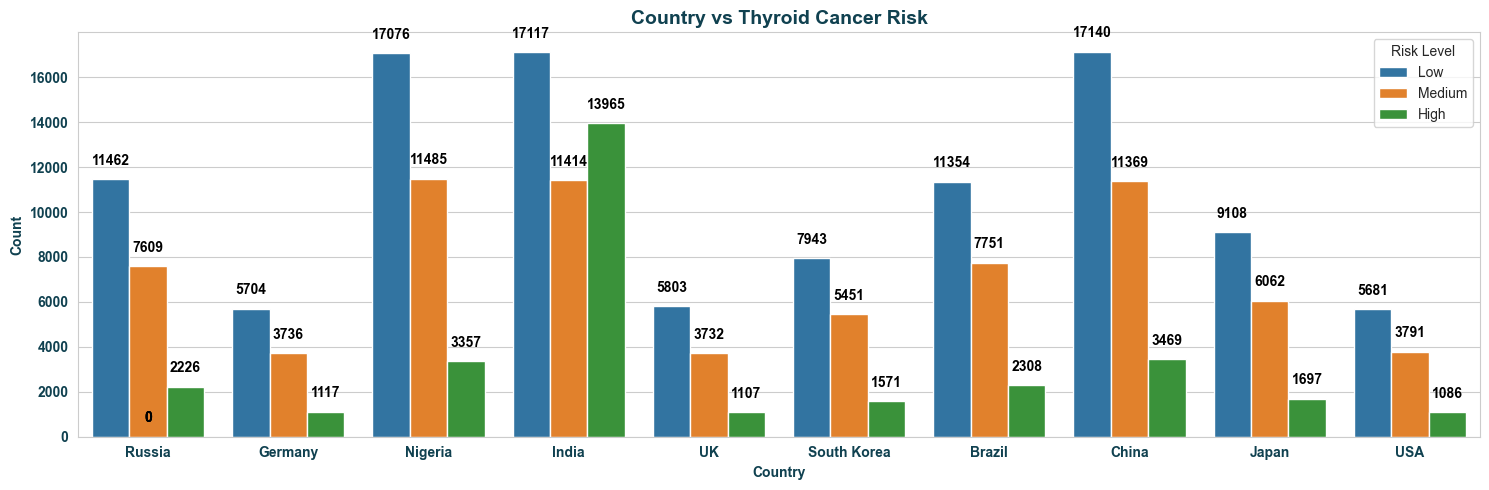

In [44]:
plt.figure(figsize=(15, 5))
palette = sns.color_palette("tab10")
ax=sns.countplot(data=df, x='Country', hue='Thyroid_Cancer_Risk', palette=palette)
plt.title("Country vs Thyroid Cancer Risk", fontsize=14, fontweight='bold',color="#104150")

plt.xlabel('Country',fontweight='bold',color="#104150")
plt.ylabel("Count",fontweight='bold',color="#104150")
plt.xticks(fontweight='bold',color="#104150")
plt.yticks(fontweight='bold',color="#104150")
plt.legend(title='Risk Level')
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,   # X-position (center of bar)
        height + 500,                    # Y-position (just above the bar)
        f'{int(height)}',                # Text (count value)
        ha='center', va='bottom', 
        fontsize=10, fontweight='bold', color='black'
    )
plt.tight_layout()
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_9652\1290726731.py:3: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  ax=sns.countplot(data=df, x='Ethnicity', hue='Thyroid_Cancer_Risk', palette=palette)


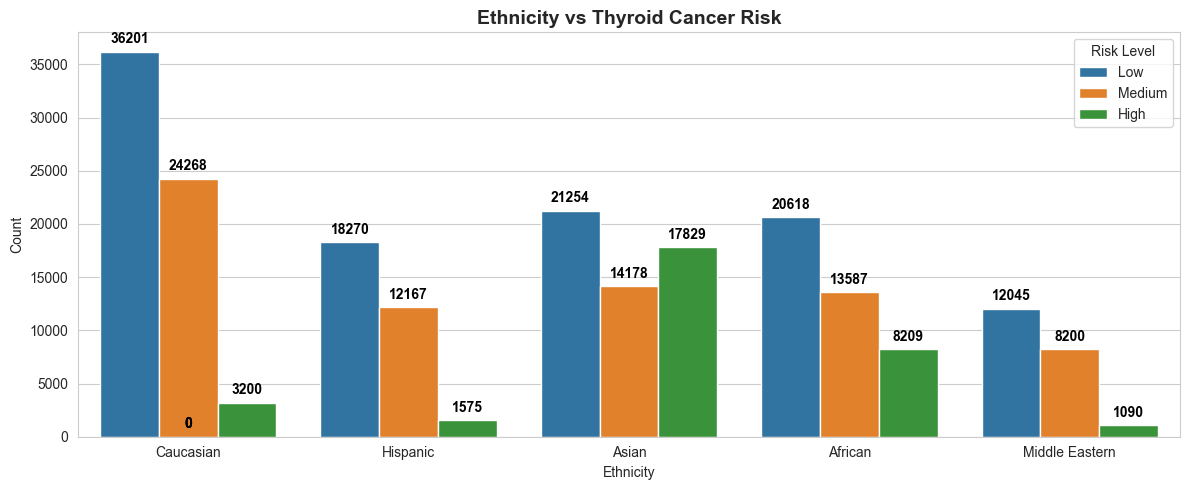

In [45]:
plt.figure(figsize=(12, 5))
palette = sns.color_palette("tab10")
ax=sns.countplot(data=df, x='Ethnicity', hue='Thyroid_Cancer_Risk', palette=palette)
plt.title("Ethnicity vs Thyroid Cancer Risk", fontsize=14, fontweight='bold')
plt.xlabel('Ethnicity')
plt.ylabel("Count")
plt.legend(title='Risk Level')
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,   # X-position (center of bar)
        height + 500,                    # Y-position (just above the bar)
        f'{int(height)}',                # Text (count value)
        ha='center', va='bottom', 
        fontsize=10, fontweight='bold', color='black'
    )
plt.tight_layout()
plt.show()


C:\Users\Hp\AppData\Local\Temp\ipykernel_9652\2537052423.py:3: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  ax=sns.countplot(data=df, x='Family_History', hue='Thyroid_Cancer_Risk', palette=palette)


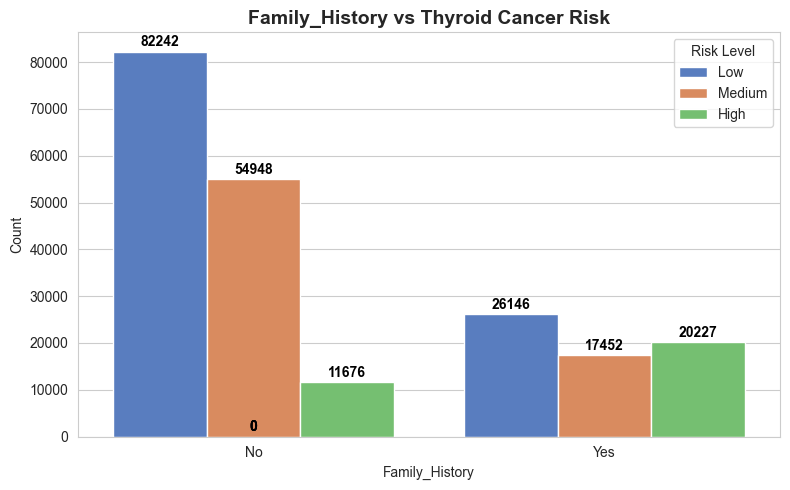

In [46]:
plt.figure(figsize=(8, 5))
palette = sns.color_palette("muted")
ax=sns.countplot(data=df, x='Family_History', hue='Thyroid_Cancer_Risk', palette=palette)
plt.title("Family_History vs Thyroid Cancer Risk", fontsize=14, fontweight='bold')
plt.xlabel('Family_History')
plt.ylabel("Count")
plt.legend(title='Risk Level')
# Add counts on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,   # X-position (center of bar)
        height + 500,                    # Y-position (just above the bar)
        f'{int(height)}',                # Text (count value)
        ha='center', va='bottom', 
        fontsize=10, fontweight='bold', color='black'
    )
plt.tight_layout()
plt.show()


C:\Users\Hp\AppData\Local\Temp\ipykernel_9652\3044300134.py:3: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  ax=sns.countplot(data=df, x= 'Radiation_Exposure', hue='Thyroid_Cancer_Risk', palette=palette)


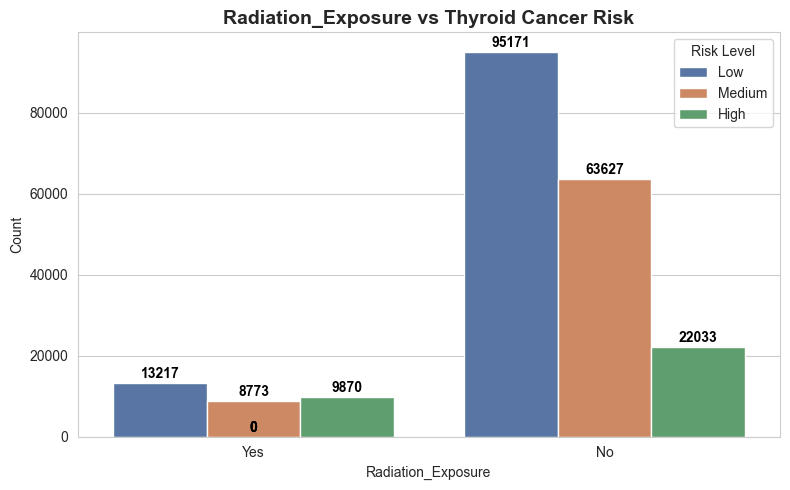

In [47]:
plt.figure(figsize=(8, 5))
palette = sns.color_palette("deep")
ax=sns.countplot(data=df, x= 'Radiation_Exposure', hue='Thyroid_Cancer_Risk', palette=palette)
plt.title("Radiation_Exposure vs Thyroid Cancer Risk", fontsize=14, fontweight='bold')
plt.xlabel( 'Radiation_Exposure')
plt.ylabel("Count")
plt.legend(title='Risk Level')
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,   # X-position (center of bar)
        height + 500,                    # Y-position (just above the bar)
        f'{int(height)}',                # Text (count value)
        ha='center', va='bottom', 
        fontsize=10, fontweight='bold', color='black'
    )
plt.tight_layout()
plt.show()


C:\Users\Hp\AppData\Local\Temp\ipykernel_9652\1883554477.py:3: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  ax=sns.countplot(data=df, x= 'Iodine_Deficiency', hue='Thyroid_Cancer_Risk', palette=palette)


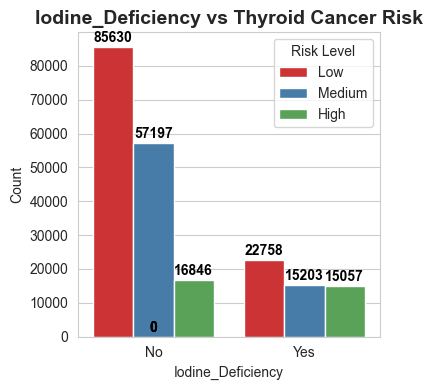

In [48]:
plt.figure(figsize=(4, 4))
palette = sns.color_palette("Set1")
ax=sns.countplot(data=df, x= 'Iodine_Deficiency', hue='Thyroid_Cancer_Risk', palette=palette)
plt.title("Iodine_Deficiency vs Thyroid Cancer Risk", fontsize=14, fontweight='bold')
plt.xlabel('Iodine_Deficiency')
plt.ylabel("Count")
plt.legend(title='Risk Level')
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,   # X-position (center of bar)
        height + 500,                    # Y-position (just above the bar)
        f'{int(height)}',                # Text (count value)
        ha='center', va='bottom', 
        fontsize=10, fontweight='bold', color='black'
    )
plt.tight_layout()
plt.show()


C:\Users\Hp\AppData\Local\Temp\ipykernel_9652\2513360921.py:3: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  ax=sns.countplot(data=df, x= 'Smoking', hue='Thyroid_Cancer_Risk', palette=palette)


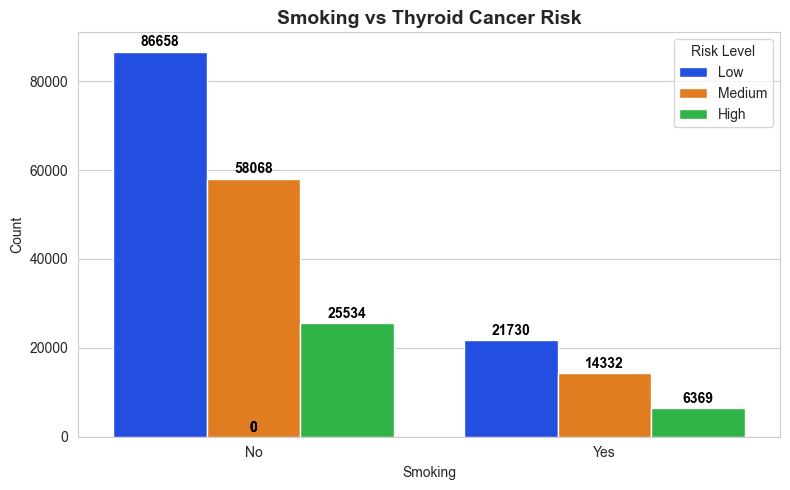

In [49]:
plt.figure(figsize=(8, 5))
palette = sns.color_palette("bright")
ax=sns.countplot(data=df, x= 'Smoking', hue='Thyroid_Cancer_Risk', palette=palette)
plt.title("Smoking vs Thyroid Cancer Risk", fontsize=14, fontweight='bold')
plt.xlabel('Smoking')
plt.ylabel("Count")
plt.legend(title='Risk Level')
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,   # X-position (center of bar)
        height + 500,                    # Y-position (just above the bar)
        f'{int(height)}',                # Text (count value)
        ha='center', va='bottom', 
        fontsize=10, fontweight='bold', color='black'
    )
plt.tight_layout()
plt.show()


C:\Users\Hp\AppData\Local\Temp\ipykernel_9652\1206934214.py:3: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  ax=sns.countplot(data=df, x= 'Obesity', hue='Thyroid_Cancer_Risk', palette=palette)


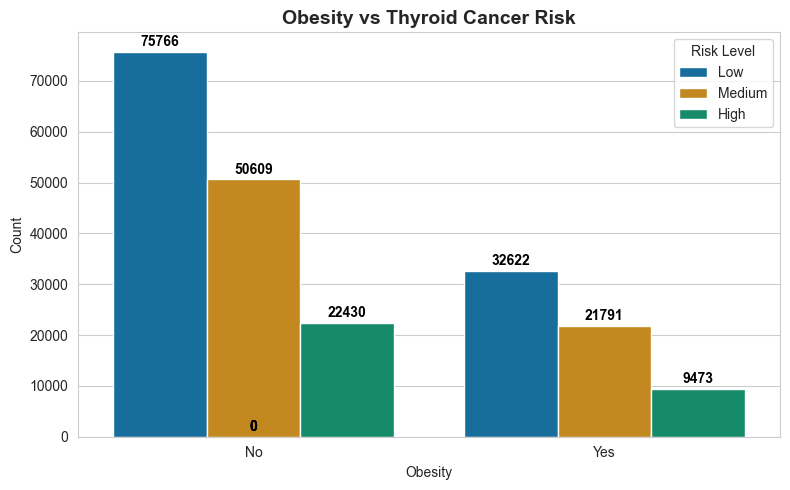

In [50]:
plt.figure(figsize=(8, 5))
palette = sns.color_palette("colorblind")
ax=sns.countplot(data=df, x= 'Obesity', hue='Thyroid_Cancer_Risk', palette=palette)
plt.title("Obesity vs Thyroid Cancer Risk", fontsize=14, fontweight='bold')
plt.xlabel('Obesity')
plt.ylabel("Count")
plt.legend(title='Risk Level')
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,   # X-position (center of bar)
        height + 500,                    # Y-position (just above the bar)
        f'{int(height)}',                # Text (count value)
        ha='center', va='bottom', 
        fontsize=10, fontweight='bold', color='black'
    )
plt.tight_layout()
plt.show()


C:\Users\Hp\AppData\Local\Temp\ipykernel_9652\389925965.py:3: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  ax=sns.countplot(data=df, x= 'Diabetes', hue='Thyroid_Cancer_Risk', palette=palette)


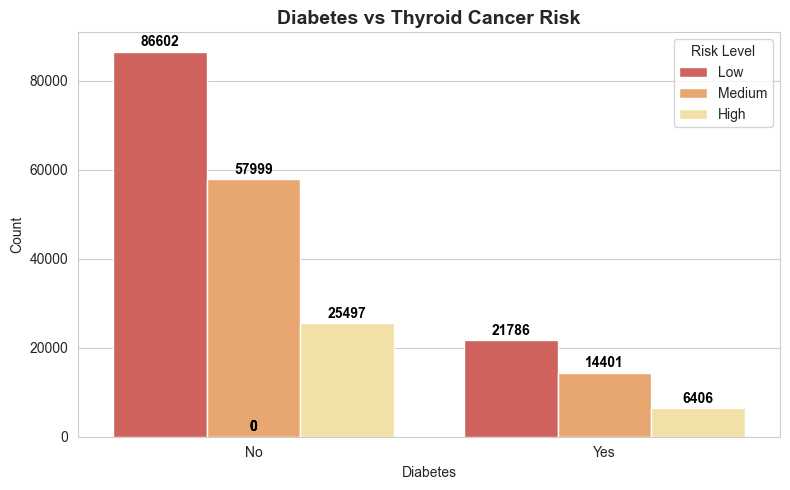

In [51]:
plt.figure(figsize=(8, 5))
palette = sns.color_palette("Spectral")
ax=sns.countplot(data=df, x= 'Diabetes', hue='Thyroid_Cancer_Risk', palette=palette)
plt.title("Diabetes vs Thyroid Cancer Risk", fontsize=14, fontweight='bold')
plt.xlabel('Diabetes')
plt.ylabel("Count")
plt.legend(title='Risk Level')
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,   # X-position (center of bar)
        height + 500,                    # Y-position (just above the bar)
        f'{int(height)}',                # Text (count value)
        ha='center', va='bottom', 
        fontsize=10, fontweight='bold', color='black'
    )
plt.tight_layout()
plt.show()


C:\Users\Hp\AppData\Local\Temp\ipykernel_9652\2813509829.py:3: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  ax=sns.countplot(data=df, x= 'Diagnosis', hue='Thyroid_Cancer_Risk', palette=palette)


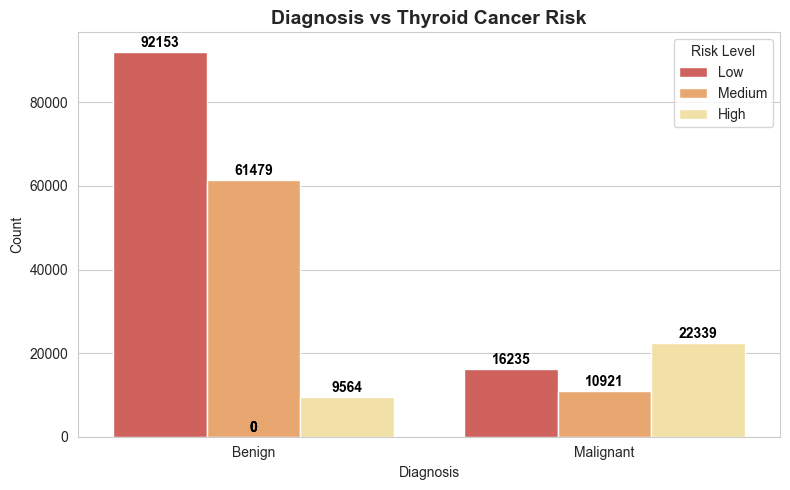

In [52]:
plt.figure(figsize=(8, 5))
palette = sns.color_palette("Spectral")
ax=sns.countplot(data=df, x= 'Diagnosis', hue='Thyroid_Cancer_Risk', palette=palette)
plt.title("Diagnosis vs Thyroid Cancer Risk", fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis')
plt.ylabel("Count")
plt.legend(title='Risk Level')
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,   # X-position (center of bar)
        height + 500,                    # Y-position (just above the bar)
        f'{int(height)}',                # Text (count value)
        ha='center', va='bottom', 
        fontsize=10, fontweight='bold', color='black'
    )
plt.tight_layout()
plt.show()


#### **Multi-Variate Analysis**

##### **Among females, which age group has the highest number of people with a high thyroid cancer risk? And among males, which age group is most affected?**

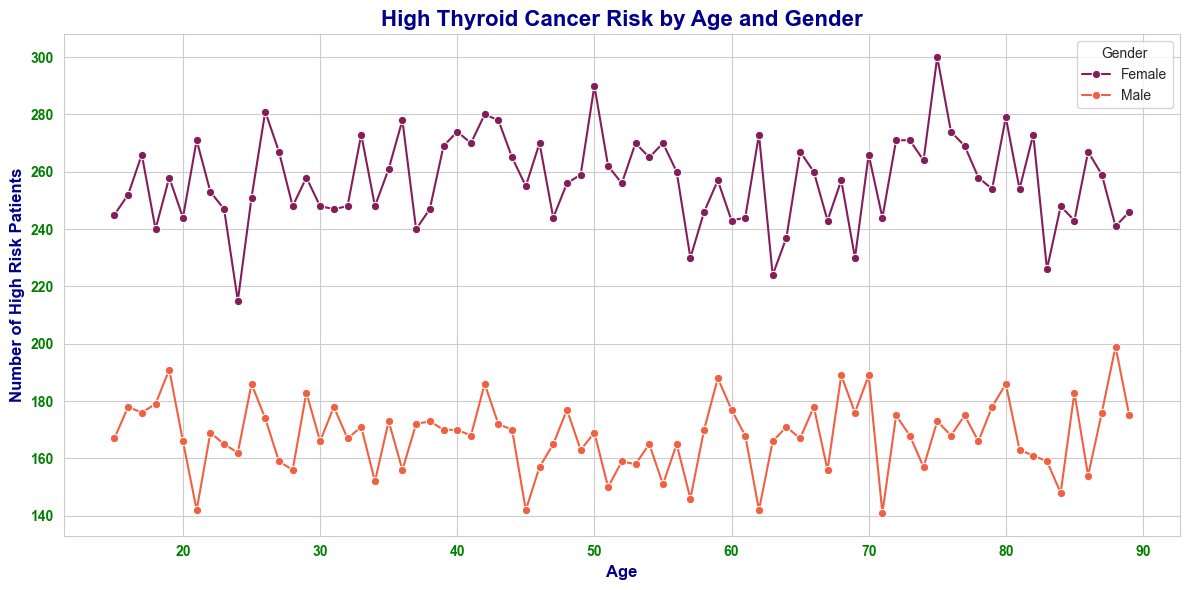

In [53]:

# Filter only high risk patients
high_risk = df[df['Thyroid_Cancer_Risk'] == 'High']

# Group by Gender and Age, then count
risk_by_gender_age = high_risk.groupby(['Gender', 'Age']).size().reset_index(name='High_Risk_Count')

# Set the plotting style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# Plotting using Seaborn
sns.lineplot(data=risk_by_gender_age, x='Age', y='High_Risk_Count', hue='Gender', marker='o', palette='rocket')

# Titles and labels
plt.title('High Thyroid Cancer Risk by Age and Gender', fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel('Age', fontsize=12,fontweight='bold', color='darkblue')
plt.ylabel('Number of High Risk Patients', fontsize=12,fontweight='bold', color='darkblue')
plt.legend(title='Gender')
plt.xticks(rotation=0,fontweight='bold', color='green')
plt.yticks(fontweight='bold', color='green')
plt.tight_layout()
plt.show()


#### **For individuals who have had radiation exposure and are at high risk of thyroid cancer, did they also have diabetes?**




In [54]:
# Filtering the data for high risk and radiation exposure
subset = df[(df['Thyroid_Cancer_Risk'] == 'High') & 
            (df['Radiation_Exposure'] == 'Yes')]
subset

,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
4,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign
6,89,Female,South Korea,Asian,Yes,Yes,No,No,Yes,No,4.70,0.62,11.73,0.01,High,Malignant
8,17,Female,Russia,African,No,Yes,No,No,No,Yes,2.30,2.60,11.89,0.81,High,Malignant
10,67,Male,Nigeria,African,No,Yes,No,No,No,No,9.65,1.82,8.17,0.35,High,Malignant
50,61,Male,Japan,Asian,Yes,Yes,No,No,No,No,5.58,1.92,8.85,0.86,High,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212553,79,Male,Brazil,Asian,Yes,Yes,No,No,No,No,4.73,1.63,10.69,2.85,High,Malignant
212589,22,Male,Nigeria,African,No,Yes,No,No,No,Yes,3.29,2.28,5.01,2.36,High,Malignant
212614,75,Female,Germany,African,No,Yes,Yes,Yes,Yes,No,6.85,1.94,8.35,3.01,High,Malignant
212616,58,Female,Russia,African,No,Yes,No,No,No,No,1.75,1.79,6.82,0.61,High,Malignant


In [55]:
#Counting the diabetes status
diabetes_counts = subset['Diabetes'].value_counts().reset_index()
diabetes_counts

,Diabetes,count
0,No,7854
1,Yes,2016


In [56]:
diabetes_counts.columns = ['Diabetes', 'Count']
diabetes_counts

,Diabetes,Count
0,No,7854
1,Yes,2016


C:\Users\Hp\AppData\Local\Temp\ipykernel_9652\663374435.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diabetes_counts, x='Diabetes', y='Count', palette='Set1')


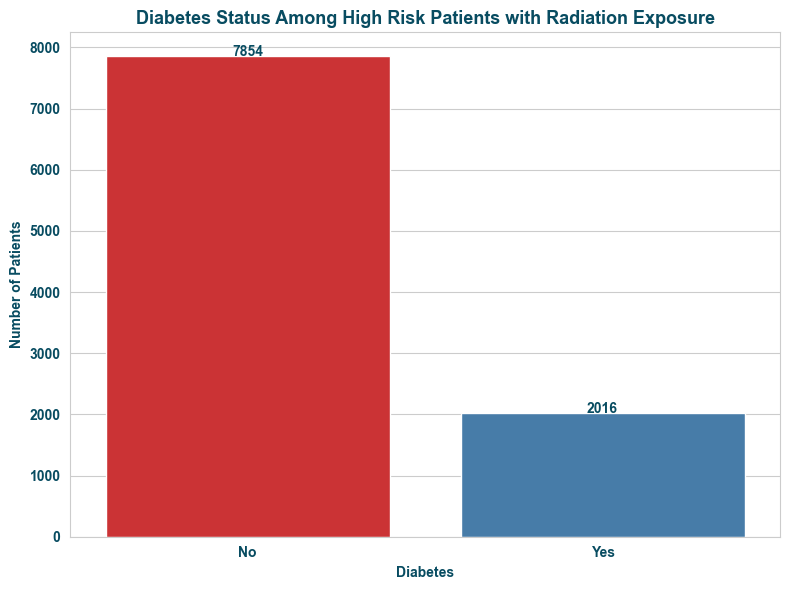

In [57]:
plt.figure(figsize=(8, 6))
sns.barplot(data=diabetes_counts, x='Diabetes', y='Count', palette='Set1')

# Annotate the bars
for i in range(len(diabetes_counts)):
    plt.text(i, diabetes_counts['Count'][i] + 1, 
             f"{diabetes_counts['Count'][i]}", 
             ha='center', fontweight='bold',color='#084C61')

plt.title('Diabetes Status Among High Risk Patients with Radiation Exposure', fontsize=13, fontweight='bold',color='#084C61')
plt.xlabel('Diabetes',fontweight='bold',color='#084C61')
plt.ylabel('Number of Patients',fontweight='bold',color='#084C61')
plt.xticks(fontweight='bold',color='#084C61')
plt.yticks(fontweight='bold',color='#084C61')
plt.tight_layout()
plt.show()


#### **Such patients with Medium Risk**

In [58]:
# Filtering the data for high risk and radiation exposure
subset = df[(df['Thyroid_Cancer_Risk'] == 'Medium') & 
            (df['Radiation_Exposure'] == 'Yes')]
subset

,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
27,76,Male,Brazil,Hispanic,Yes,Yes,No,No,No,No,4.99,1.56,6.48,1.54,Medium,Benign
70,76,Male,Nigeria,Caucasian,No,Yes,Yes,No,No,No,7.00,2.15,6.97,2.01,Medium,Benign
81,85,Female,Nigeria,Caucasian,No,Yes,Yes,No,Yes,Yes,6.50,2.70,8.43,0.02,Medium,Malignant
107,61,Male,Japan,Asian,No,Yes,No,No,No,No,8.28,2.34,5.08,2.03,Medium,Malignant
133,76,Female,China,Caucasian,No,Yes,No,No,No,No,9.90,1.93,8.18,0.47,Medium,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212568,83,Female,South Korea,Caucasian,No,Yes,No,No,No,No,9.11,1.17,4.98,2.81,Medium,Benign
212577,28,Male,China,Asian,No,Yes,No,No,No,Yes,3.26,2.30,9.48,0.52,Medium,Benign
212615,61,Male,Nigeria,Caucasian,No,Yes,No,No,No,Yes,2.86,2.09,9.97,1.10,Medium,Benign
212676,56,Male,Japan,Hispanic,No,Yes,No,No,No,No,6.36,2.24,11.82,4.86,Medium,Benign


In [59]:
#Counting the diabetes status
diabetes_counts = subset['Diabetes'].value_counts().reset_index()
diabetes_counts

,Diabetes,count
0,No,7006
1,Yes,1767


In [60]:
diabetes_counts.columns = ['Diabetes', 'Count']
diabetes_counts

,Diabetes,Count
0,No,7006
1,Yes,1767


C:\Users\Hp\AppData\Local\Temp\ipykernel_9652\498617329.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diabetes_counts, x='Diabetes', y='Count', palette='Spectral')


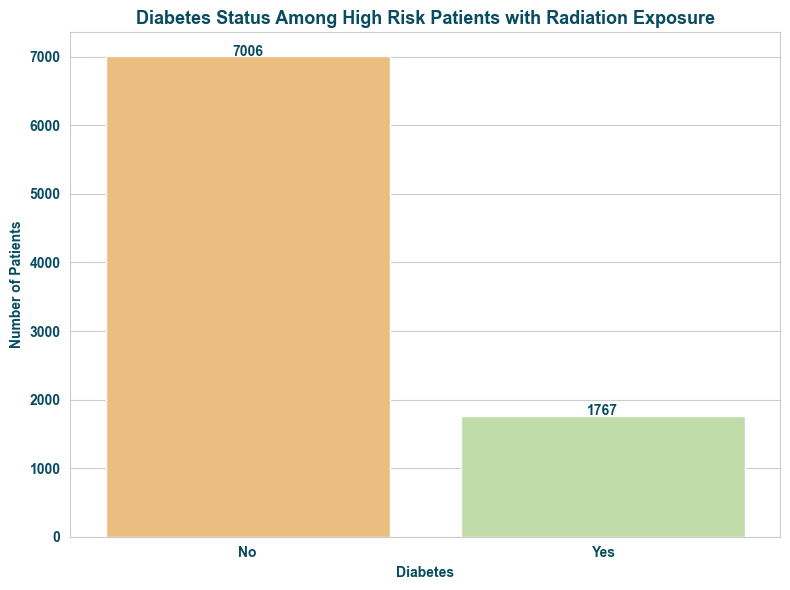

In [61]:
plt.figure(figsize=(8, 6))
sns.barplot(data=diabetes_counts, x='Diabetes', y='Count', palette='Spectral')

# Annotate the bars
for i in range(len(diabetes_counts)):
    plt.text(i, diabetes_counts['Count'][i] + 1, 
             f"{diabetes_counts['Count'][i]}", 
             ha='center', fontweight='bold',color='#084C61')

plt.title('Diabetes Status Among High Risk Patients with Radiation Exposure', fontsize=13, fontweight='bold',color='#084C61')
plt.xlabel('Diabetes',fontweight='bold',color='#084C61')
plt.ylabel('Number of Patients',fontweight='bold',color='#084C61')
plt.xticks(fontweight='bold',color='#084C61')
plt.yticks(fontweight='bold',color='#084C61')
plt.tight_layout()
plt.show()


#### **Among individuals who have both diabetes and obesity, does gender influence the likelihood of being in the high-risk category?**



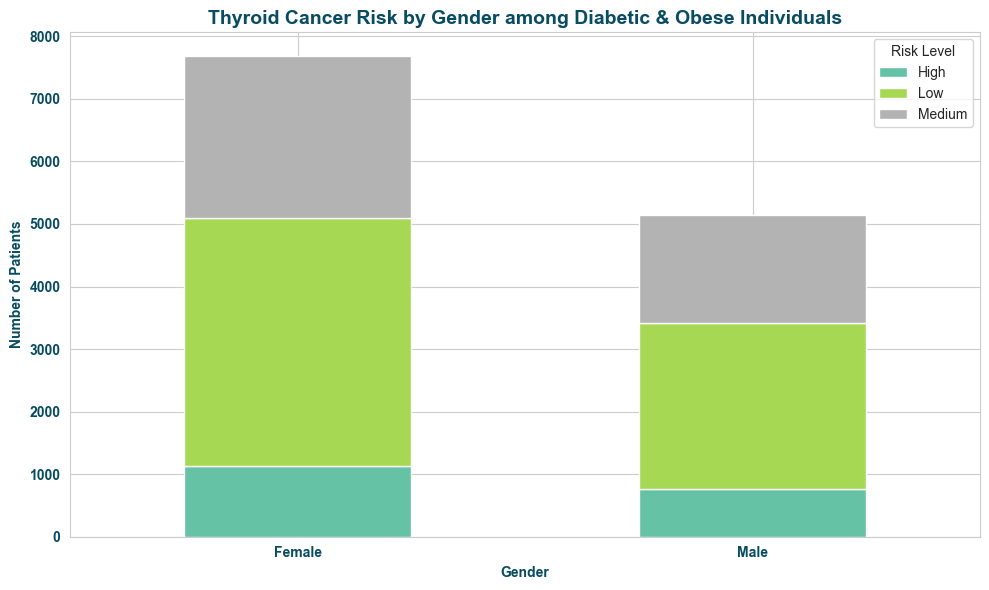

In [62]:
#Filtering the individuals with both Diabetes and Obesity
subset = df[(df['Diabetes'] == 'Yes') & (df['Obesity'] == 'Yes')]

# Grouping by Gender and Thyroid_Cancer_Risk
grouped = subset.groupby(['Gender', 'Thyroid_Cancer_Risk']).size().reset_index(name='Count')

#Pivoting for stacked bar chart
pivot_data = grouped.pivot(index='Gender', columns='Thyroid_Cancer_Risk', values='Count') #.fillna(0)

#Plotting the stacked bar chart
pivot_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')

plt.title("Thyroid Cancer Risk by Gender among Diabetic & Obese Individuals", fontsize=14, fontweight='bold',color='#084C61')
plt.xlabel("Gender",fontweight='bold',color='#084C61')
plt.ylabel("Number of Patients",fontweight='bold',color='#084C61')
plt.legend(title="Risk Level")
plt.xticks(rotation=0,fontweight='bold',color='#084C61')
plt.yticks(fontweight='bold',color='#084C61')
plt.tight_layout()
plt.show()


#### **Is high thyroid cancer risk more prevalent among female smokers or male smokers?**



C:\Users\Hp\AppData\Local\Temp\ipykernel_9652\496542200.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_counts, x='Gender', y='High_Risk_Smoker_Count', palette='muted')


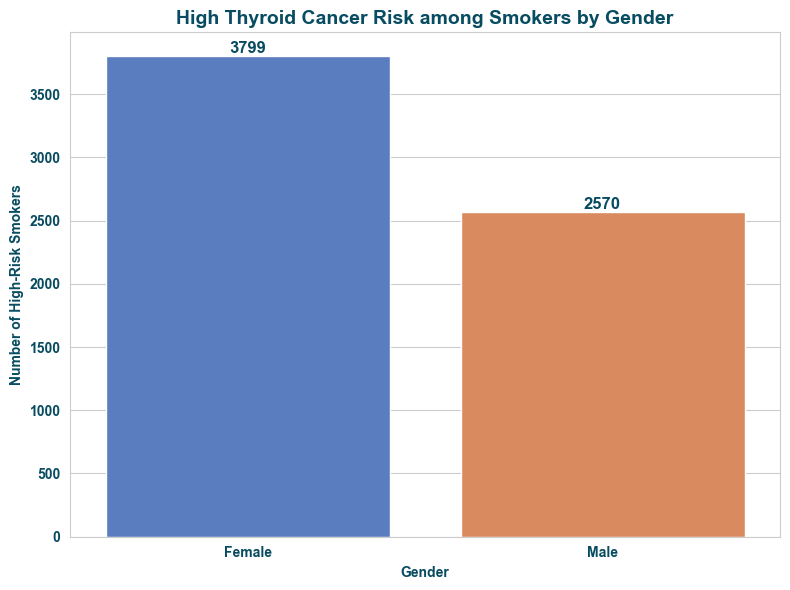

In [63]:
# Step 1: Filter only high-risk individuals who are smokers
high_risk_smokers = df[(df['Thyroid_Cancer_Risk'] == 'High') & (df['Smoking'] == 'Yes')]

# Step 2: Count the number of high-risk smokers by gender
gender_counts = high_risk_smokers['Gender'].value_counts().reset_index()
gender_counts.columns = ['Gender', 'High_Risk_Smoker_Count']

#Visualization
plt.figure(figsize=(8, 6))
sns.barplot(data=gender_counts, x='Gender', y='High_Risk_Smoker_Count', palette='muted')

# Annotate count values
for i, row in gender_counts.iterrows():
    plt.text(i, row['High_Risk_Smoker_Count'] + 1, int(row['High_Risk_Smoker_Count']), # type: ignore
             ha='center', va='bottom', fontsize=12, fontweight='bold',color='#084C61')

plt.title('High Thyroid Cancer Risk among Smokers by Gender', fontsize=14, fontweight='bold',color='#084C61')
plt.ylabel('Number of High-Risk Smokers', fontweight='bold',color='#084C61')
plt.xlabel('Gender',fontweight='bold',color='#084C61')
plt.xticks(fontweight='bold',color='#084C61')
plt.yticks(fontweight='bold',color='#084C61')
plt.tight_layout()
plt.show()


#### **For individuals with iodine deficiency, what were their average TSH levels, and what was the distribution of thyroid cancer risk among them?**

In [64]:
# Step 1: Filter people with iodine deficiency
iodine_def = df[df['Iodine_Deficiency'] == 'Yes']

# Step 2: Average TSH level
avg_tsh = iodine_def['TSH_Level'].mean()
print(f"Average TSH Level for individuals with iodine deficiency: {avg_tsh:.2f}")

Average TSH Level for individuals with iodine deficiency: 5.04


C:\Users\Hp\AppData\Local\Temp\ipykernel_9652\3846847342.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risk_distribution, x='Risk_Level', y='Count', palette='colorblind')


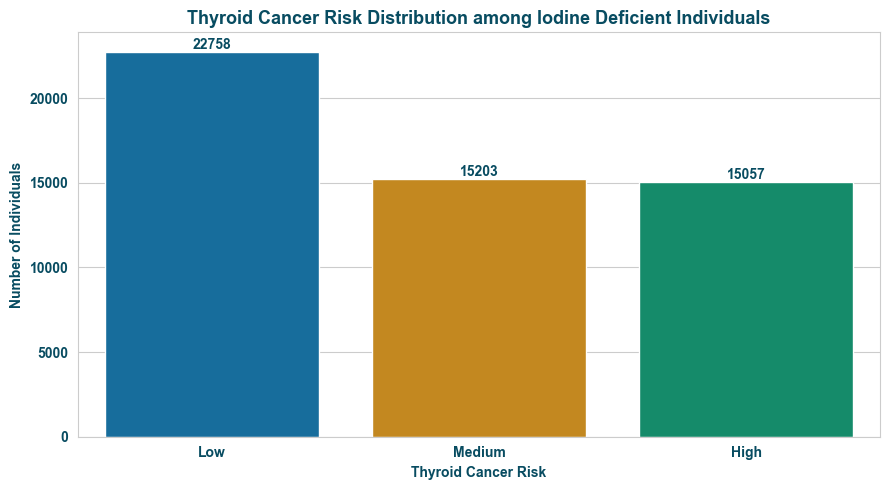

In [65]:
# Step 3: Distribution of Thyroid Cancer Risk
risk_distribution = iodine_def['Thyroid_Cancer_Risk'].value_counts().reset_index()
risk_distribution.columns = ['Risk_Level', 'Count']


plt.figure(figsize=(9, 5))
sns.barplot(data=risk_distribution, x='Risk_Level', y='Count', palette='colorblind')

# Annotate values
for i, row in risk_distribution.iterrows():
    plt.text(i, row['Count'] + 1, int(row['Count']), # type: ignore
             ha='center', va='bottom',  fontweight='bold',color='#084C61')

plt.title('Thyroid Cancer Risk Distribution among Iodine Deficient Individuals', fontsize=13,  fontweight='bold',color='#084C61')
plt.xlabel('Thyroid Cancer Risk', fontweight='bold',color='#084C61')
plt.ylabel('Number of Individuals', fontweight='bold',color='#084C61')
plt.xticks( fontweight='bold',color='#084C61')
plt.yticks( fontweight='bold',color='#084C61')
plt.tight_layout()
plt.show()


#### **Among the patients with low TSH levels and high thyroid cancer risk, what were the most common diagnoses?**

In [66]:
# Step 1: Define TSH low threshold (e.g., < 0.4 is considered low)
low_tsh_threshold = 0.4

# Step 2: Filter data
low_tsh_high_risk = df[(df['TSH_Level'] < low_tsh_threshold) & (df['Thyroid_Cancer_Risk'] == 'High')]

# Step 3: Count diagnoses
diagnosis_counts = low_tsh_high_risk['Diagnosis'].value_counts().reset_index()
diagnosis_counts.columns = ['Diagnosis', 'Count']

# Optional: Show top 5
print("Top Diagnoses for Low TSH + High Risk Patients:")
print(diagnosis_counts.head())


Top Diagnoses for Low TSH + High Risk Patients:
   Diagnosis  Count
0  Malignant    722
1     Benign    315


C:\Users\Hp\AppData\Local\Temp\ipykernel_9652\1946027181.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diagnosis_counts.head(5), x='Diagnosis', y='Count', palette='magma')


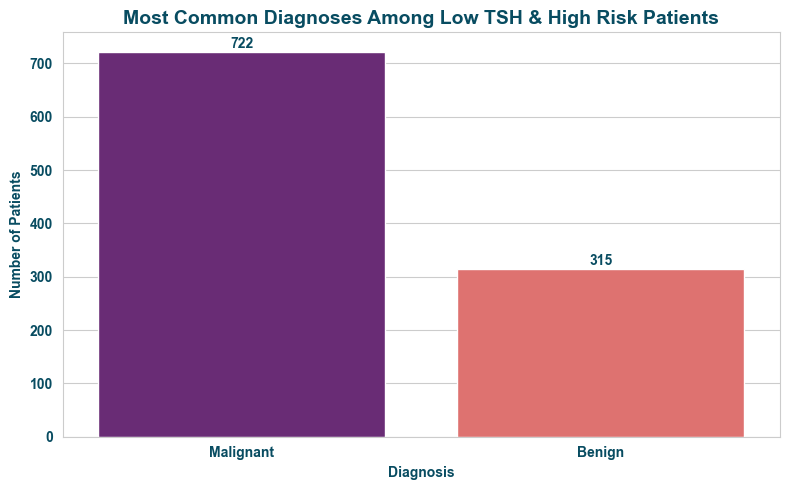

In [67]:
plt.figure(figsize=(8, 5))
sns.barplot(data=diagnosis_counts.head(5), x='Diagnosis', y='Count', palette='magma')

# Add counts on top
for i, row in diagnosis_counts.head(5).iterrows():
    plt.text(i, row['Count'] + 1, int(row['Count']), # type: ignore
             ha='center', va='bottom', fontsize=10,fontweight='bold',color='#084C61')

plt.title("Most Common Diagnoses Among Low TSH & High Risk Patients", fontsize=14,fontweight='bold',color='#084C61')
plt.xlabel("Diagnosis",fontweight='bold',color='#084C61')
plt.ylabel("Number of Patients",fontweight='bold',color='#084C61')
plt.xticks( fontweight='bold',color='#084C61')
plt.yticks( fontweight='bold',color='#084C61')
plt.tight_layout()
plt.show()


### **ENCODING THE CATEGORICAL FEATURES**

| Comparison    | Interpretation                   | Shape (Skewness)        |
| ------------- | -------------------------------- | ----------------------- |
| Mean ≈ Median | Data is **symmetric**            | Normal distribution     |
| Mean > Median | **Right-skewed** (tail on right) | e.g. income data        |
| Mean < Median | **Left-skewed** (tail on left)   | e.g. age at retirement  |

#### Why Is This Useful in Data Cleaning?
- If data is symmetric, you can use mean for imputation or scaling.
- If data is skewed, prefer median to avoid bias from outliers.
- Comparing Mean vs Median is very important — it helps you understand distribution shape, detect skewness, and decide how to clean, transform, or impute your data later in ML.

- majority = df['Diagnosis'].value_counts().max()
- minority = df['Diagnosis'].value_counts().min()
- imbalance_ratio = majority / minority


| Ratio  | Interpretation          |
| ------ | ----------------------- |
| `<= 2` |  Balanced or tolerable |
| `> 3`  |  Imbalance — fix it   |
| `> 5`  |  High imbalance        |
| `> 10` |  *Critical*           |

| 🔧 Technique                  |  Use Case                                                                  |
| ----------------------------- | ---------------------------------------------------------------------------- |
| **Oversampling** (e.g. SMOTE) | Duplicate or synthesize minority rows                                        |
| **Undersampling**             | Remove extra majority class rows                                             |
| **Balanced algorithms**       | E.g., `class_weight='balanced'` in logistic regression, SVM, etc.            |
| **Anomaly Detection**         | Kabhi kabhi minority class itni rare hoti hai ke alag algorithm use hota hai |

---
| Sawal                         |  Jawaab                                |
| ------------------------------- | --------------------------------------- |
| Data real hai to balance karna? | *Modeling ke waqt zaroori hai*          |
| Class imbalance ratio?          | `majority / minority`                   |
| Kab fix karein?                 | Jab ratio `> 3` ho ya minority < 20% ho |



---



| Minority Class Percentage    |  Interpretation                                     |
| ---------------------------- | ----------------------------------------------------- |
| **50-50%**                   |  Perfectly balanced                                  |
| **60-40% / 70-30%**          |  Mild imbalance (usually okay)                      |
| **80-20% or worse**          |  Imbalanced (watch out)                             |
| **90-10% or worse**          |  Severely imbalanced                                 |
| **< 5%** (e.g., 95-5%)       |  *Critical imbalance* — special techniques required |


- If any class is < 20% → it’s considered **imbalanced**
- If any class is < 10% → it's **severely imbalanced**

- counts = df['Diagnosis'].value_counts(normalize=True) * 100
- print(counts.round(2))
- Output:
- No Cancer     91.7%
- Cancer         8.3%

- That 8.3% is minority → imbalance confirmed
- So now you must consider handling it during modeling

|  Step                            |  What You Do                               |
| --------------------------------- | -------------------------------------------- |
| 1. `value_counts(normalize=True)` | To get %                                     |
| 2. See if any class is < 20%      | Class imbalance detected                     |
| 3. If < 10% → Apply special care  | Use SMOTE, undersampling, class\_weight etc. |





##  Encoding Categorical Data using Scikit-learn

In machine learning, categorical data needs to be converted into numerical format before training a model. Scikit-learn provides different encoding techniques suitable for different types of categorical features.

---

###  1. Ordinal Features → `OrdinalEncoder`

####  Use When:
- The categories have a **natural, meaningful order**.
- But the exact difference between them is **not known**.

####  Example from Dataset:
- **Thyroid_Cancer_Risk**: ['Low', 'Medium', 'High']

####  Code:
```python
from sklearn.preprocessing import OrdinalEncoder

ordinal_enc = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
df[['Thyroid_Cancer_Risk']] = ordinal_enc.fit_transform(df[['Thyroid_Cancer_Risk']])
